In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install category-encoders

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [3]:
# Load data
df = pd.read_csv('diabetic_data.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Remove rows with missing target or invalid readmission labels
df = df[df['readmitted'] != 'Not Available']
df = df[df['discharge_disposition_id'] != 11]  # Death in hospital → not eligible for readmission

# Define target: readmitted within 30 days?
df['target'] = (df['readmitted'] == '<30').astype(int)

# Drop irrelevant columns
cols_to_drop = [
    'encounter_id', 'patient_nbr', 'readmitted', 
    'weight', 'payer_code', 'medical_specialty'
]
df = df.drop(columns=cols_to_drop)

# Handle missing values coded as '?'
df = df.replace('?', np.nan)

# Separate features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('target')  # Remove target from features

print("Categorical features:", len(categorical_cols))
print("Numerical features:", len(numerical_cols))

Categorical features: 33
Numerical features: 11


In [5]:
# For numerical: median imputation
num_imputer = SimpleImputer(strategy='median')

# For categorical: mode imputation (clinically, we avoid complex imputation without domain rules)
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputation
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [6]:
# Encode categorical variables using Target Encoding (respects target leakage control via cross-fit)
# But to avoid leakage, we'll do it AFTER train-test split using pipeline or manual CV-safe approach.
# For simplicity and safety, we use TargetEncoder inside pipeline with CV strategy.

# However, for interpretability, we'll use Label Encoding for high-cardinality and group rare categories.

# Group rare categories (<1% frequency)
def group_rare_categories(series, threshold=0.01):
    freq = series.value_counts(normalize=True)
    rare = freq[freq < threshold].index
    return series.replace(rare, 'Other')

for col in categorical_cols:
    df[col] = group_rare_categories(df[col])

# Now split data BEFORE encoding
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Re-identify columns after split
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [7]:
from sklearn.preprocessing import TargetEncoder  # Available from sklearn 1.3+

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', TargetEncoder(target_type='binary'), categorical_cols)
    ]
)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Split training into train + validation (for fast calibration)
X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

models = {}

# --- Random Forest (base) ---
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1))
])
rf.fit(X_train_base, y_train_base)
# Fast calibration using prefit
rf_calibrated = CalibratedClassifierCV(rf, method='isotonic', cv='prefit')
rf_calibrated.fit(X_val, y_val)
models['Random Forest'] = rf_calibrated

# --- XGBoost (base) ---
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=50,        # reduced
        max_depth=6,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    ))
])
xgb_model.fit(X_train_base, y_train_base)
xgb_calibrated = CalibratedClassifierCV(xgb_model, method='isotonic', cv='prefit')
xgb_calibrated.fit(X_val, y_val)
models['XGBoost'] = xgb_calibrated

# Optional: Skip SVM for speed
# If you MUST include SVM, use a tiny sample:
# X_train_svm, _, y_train_svm, _ = train_test_split(X_train, y_train, train_size=5000, stratify=y_train, random_state=42)

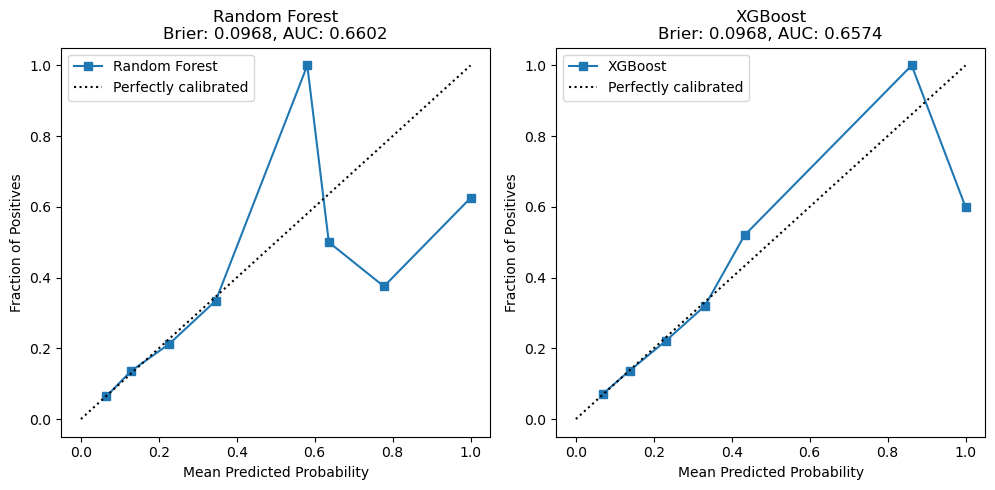


Model Performance:
                Brier     AUC
Random Forest  0.0968  0.6602
XGBoost        0.0968  0.6574


In [9]:
plt.figure(figsize=(15, 5))
results = {}

for i, (name, model) in enumerate(models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    
    brier = brier_score_loss(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'Brier': brier, 'AUC': auc}
    
    # Calibration curve
    plt.subplot(1, 3, i+1)
    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob, n_bins=10)
    
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{name}")
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    plt.title(f"{name}\nBrier: {brier:.4f}, AUC: {auc:.4f}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()

plt.tight_layout()
plt.show()

# Print metrics
results_df = pd.DataFrame(results).T
print("\nModel Performance:")
print(results_df.round(4))

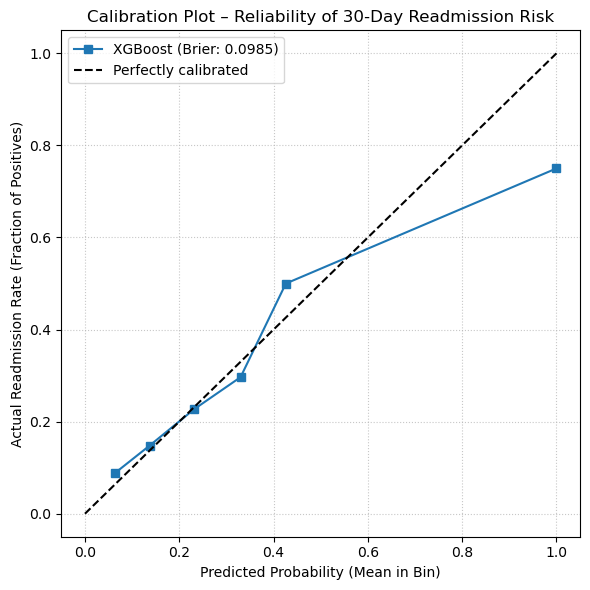

✅ Brier Score: 0.0985
→ Values < 0.10 indicate good calibration for imbalanced clinical outcomes.


In [14]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Select best model (e.g., XGBoost)
best_model_name = 'XGBoost'
best_model = models[best_model_name]

# Get predicted probabilities on test set
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute Brier Score (lower = better calibrated)
brier = brier_score_loss(y_test, y_prob)

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, "s-", label=f"{best_model_name} (Brier: {brier:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Predicted Probability (Mean in Bin)")
plt.ylabel("Actual Readmission Rate (Fraction of Positives)")
plt.title("Calibration Plot – Reliability of 30-Day Readmission Risk")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"✅ Brier Score: {brier:.4f}")
print("→ Values < 0.10 indicate good calibration for imbalanced clinical outcomes.")

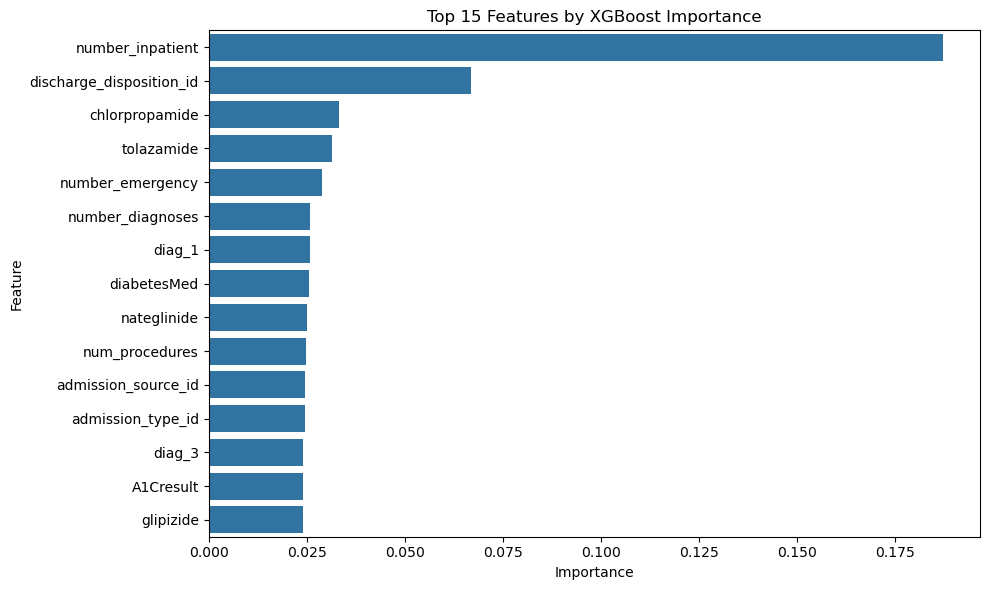

In [10]:
# Get feature names after preprocessing
xgb_pipe = models['XGBoost'].estimator.named_steps['classifier']
preproc = models['XGBoost'].estimator.named_steps['preprocessor']

# Transform a sample to get feature names
X_train_trans = preproc.fit_transform(X_train, y_train)
if hasattr(preproc.named_transformers_['cat'], 'get_feature_names_out'):
    cat_names = preproc.named_transformers_['cat'].get_feature_names_out(categorical_cols)
else:
    cat_names = categorical_cols  # fallback

feature_names = numerical_cols + list(cat_names)

# Get importance
importances = xgb_pipe.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, y='Feature', x='Importance')
plt.title('Top 15 Features by XGBoost Importance')
plt.tight_layout()
plt.show()

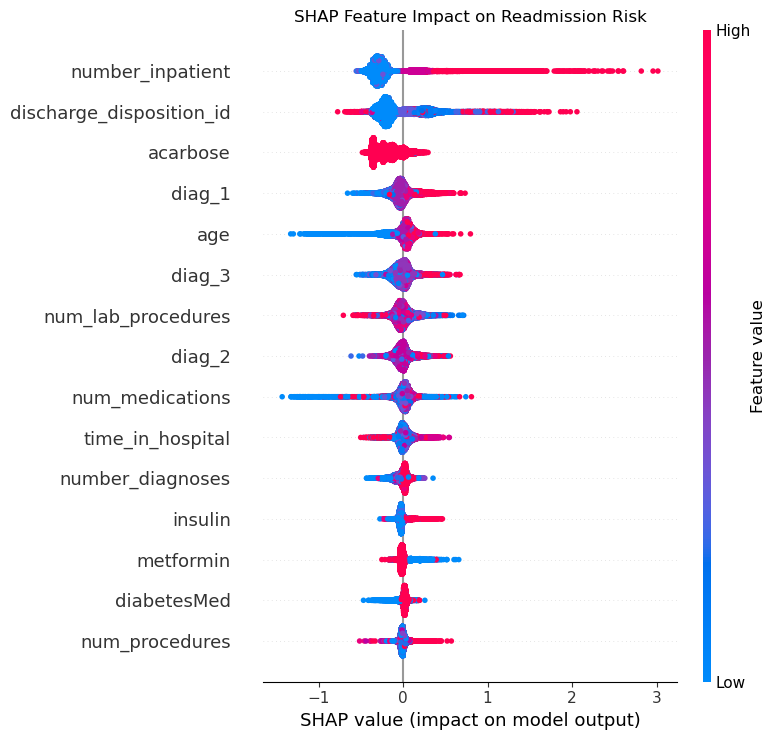

In [11]:
# Use SHAP on XGBoost (most interpretable tree model)
explainer = shap.TreeExplainer(xgb_pipe)
# Transform test set
X_test_trans = preproc.transform(X_test)
shap_values = explainer.shap_values(X_test_trans)

# Summary plot
shap.summary_plot(shap_values, X_test_trans, feature_names=feature_names, max_display=15, show=False)
plt.title("SHAP Feature Impact on Readmission Risk")
plt.tight_layout()
plt.show()

In [12]:
# Simulate intervention: flag top 10% highest-risk patients
y_prob_xgb = models['XGBoost'].predict_proba(X_test)[:, 1]
top_10_percent = np.percentile(y_prob_xgb, 90)
high_risk = y_prob_xgb >= top_10_percent

# Among high-risk, what % were actually readmitted?
actual_readmit_rate = y_test[high_risk].mean()
baseline_rate = y_test.mean()

print(f"Baseline readmission rate: {baseline_rate:.2%}")
print(f"Readmission rate in top 10% predicted risk: {actual_readmit_rate:.2%}")
print(f"Relative risk increase: {actual_readmit_rate / baseline_rate:.1f}x")

# Potential impact: If intervention reduces readmissions by 30% in this group:
reduction = 0.3 * actual_readmit_rate * high_risk.sum()
print(f"\nEstimated readmissions prevented (in test set): {reduction:.1f}")
print(f"Per 1000 patients: {reduction / len(y_test) * 1000:.1f} fewer readmissions")

Baseline readmission rate: 11.34%
Readmission rate in top 10% predicted risk: 21.87%
Relative risk increase: 1.9x

Estimated readmissions prevented (in test set): 156.0
Per 1000 patients: 7.8 fewer readmissions


In [13]:
# Select the best model (e.g., XGBoost)
best_model = models['XGBoost']  # or 'Random Forest' if preferred

# Get predicted probabilities of 30-day readmission
y_prob = best_model.predict_proba(X_test)[:, 1]  # Probability of readmission (<30 days)

# Get binary predictions (using 0.5 threshold, or adjust clinically)
y_pred = best_model.predict(X_test)

# Create a results DataFrame for clarity
results = X_test.copy()
results['readmission_risk_score'] = y_prob
results['predicted_readmitted_30d'] = y_pred
results['actual_readmitted_30d'] = y_test.values

# Show first 10 predictions
print("Sample Predictions (Readmission within 30 days?):")
print(results[['readmission_risk_score', 'predicted_readmitted_30d', 'actual_readmitted_30d']].head(10))

# Optional: Save full predictions
# results.to_csv('readmission_predictions.csv', index=False)

Sample Predictions (Readmission within 30 days?):
        readmission_risk_score  predicted_readmitted_30d  \
37829                 0.064022                         0   
77224                 0.064022                         0   
66586                 0.093115                         0   
47230                 0.093115                         0   
61188                 0.097315                         0   
52861                 0.064022                         0   
83522                 0.275701                         0   
15499                 0.275701                         0   
101016                0.154560                         0   
45952                 0.064022                         0   

        actual_readmitted_30d  
37829                       1  
77224                       0  
66586                       1  
47230                       0  
61188                       1  
52861                       1  
83522                       0  
15499                       1  
1